# GMM + Mahalanobis Anomaly Detection
## Zero-Shot Industrial Anomaly Detection via Deep Feature Modeling
### Feature Extractor: ResNet18 | Dataset: MVTec AD

**Pipeline:**
Raw Image → ResNet18 (512-dim) → PCA (25-dim) → GMM → Mahalanobis Distance → Anomaly Score

**Key Principles:**
- Train on normal images only
- PCA and GMM fitted on training data only (no data leakage)
- Threshold derived from training scores only
- Evaluated using AUC-ROC and Precision-Recall

In [1]:
# ── Imports + Configuration ───────────────────────────────────────────────────
# All libraries and global settings for the full pipeline.
# Change BACKBONE and FEATURE_DIM here to switch between ResNet18 and ResNet50.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from scipy import linalg
from google.colab import drive

# ── Global Configuration ──────────────────────────────────────────────────────
BACKBONE         = 'resnet18'   # resnet18 or resnet50
FEATURE_DIM      = 512          # resnet18=512, resnet50=2048
PCA_N_COMPONENTS = 25           # fixed dims for stable GMM covariance
PERCENTILE       = 95           # anomaly threshold percentile

print(f"Backbone       : {BACKBONE}")
print(f"Feature dim    : {FEATURE_DIM}")
print(f"PCA components : {PCA_N_COMPONENTS}")
print(f"Threshold pct  : {PERCENTILE}")

Backbone       : resnet18
Feature dim    : 512
PCA components : 25
Threshold pct  : 95


In [2]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
# Connects Colab to Drive so dataset and all saved files are accessible.

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Dataset Paths + Auto-Select All Categories ────────────────────────────────
# Automatically detects and runs ALL 15 MVTec AD categories.
# No manual input needed — every category found in the archive folder is used.
# Change RUN_CATEGORIES below if you want a specific subset.

BASE_PATH = '/content/drive/MyDrive/Zero Shot Anomaly Detection/Data/archive'

ALL_CATEGORIES = sorted([
    d for d in os.listdir(BASE_PATH)
    if os.path.isdir(os.path.join(BASE_PATH, d))
    and 'train' in os.listdir(os.path.join(BASE_PATH, d))
])

# ── Set which categories to run ───────────────────────────────────────────────
# Option A: run everything (recommended)
CATEGORIES = ALL_CATEGORIES

# Option B: run a specific subset — uncomment and edit this line instead
# CATEGORIES = ['bottle', 'carpet', 'hazelnut', 'screw']

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 55)
print(f"Running pipeline on {len(CATEGORIES)} categories")
print("=" * 55)
for cat in CATEGORIES:
    n = len(os.listdir(os.path.join(BASE_PATH, cat, 'train', 'good')))
    print(f"  {cat:<20} ({n} training images)")
print("=" * 55)

Running pipeline on 15 categories
  bottle               (209 training images)
  cable                (224 training images)
  capsule              (219 training images)
  carpet               (280 training images)
  grid                 (264 training images)
  hazelnut             (391 training images)
  leather              (245 training images)
  metal_nut            (220 training images)
  pill                 (267 training images)
  screw                (320 training images)
  tile                 (230 training images)
  toothbrush           (60 training images)
  transistor           (213 training images)
  wood                 (247 training images)
  zipper               (240 training images)


In [4]:
# ── ResNet18 Feature Extractor ────────────────────────────────────────────────
# Loads pretrained ResNet18 and strips the final classification layer.
# The remaining network outputs a 512-dimensional feature vector per image.
#
# Why strip the fc layer?
#   The fc layer maps 512 features to 1000 ImageNet class scores.
#   We want the 512-dim representation of image content, not class predictions.
#
# Why eval() mode?
#   Disables BatchNorm and Dropout randomness so features are deterministic.
#
# Why torch.no_grad()?
#   We are not training anything. Disabling gradients saves memory and
#   speeds up inference significantly.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print(f"ResNet18 loaded")
print(f"Output feature size: {FEATURE_DIM}-dimensional vector")

# ── ImageNet Preprocessing ────────────────────────────────────────────────────
# These exact mean and std values must be used because ResNet18
# was trained on ImageNet with this normalization.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class ImageFolderFlat(Dataset):
    """Loads all images from a flat folder (no subfolders)."""
    def __init__(self, folder_path, transform=None):
        self.transform   = transform
        self.image_paths = sorted([
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
        ])
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img

def extract_features(folder_path, batch_size=32):
    """
    Passes all images in a folder through ResNet18.
    Returns numpy array of shape (N, 512).
    """
    dataset    = ImageFolderFlat(folder_path, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=False, num_workers=2)
    all_feats  = []
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            feats = feature_extractor(batch)        # (B, 512, 1, 1)
            feats = feats.squeeze(-1).squeeze(-1)   # (B, 512)
            all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats, axis=0)        # (N, 512)

# ── Verify on first category ──────────────────────────────────────────────────
print(f"\nVerifying on: {CATEGORIES[0]}")
sample = extract_features(
    os.path.join(BASE_PATH, CATEGORIES[0], 'train', 'good')
)
print(f"  Images     : {sample.shape[0]}")
print(f"  Feature dim: {sample.shape[1]}  (expected {FEATURE_DIM})")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


ResNet18 loaded
Output feature size: 512-dimensional vector

Verifying on: bottle
  Images     : 209
  Feature dim: 512  (expected 512)


In [5]:
# ── Extract + Save Features for All Categories ────────────────────────────────
# Runs ResNet18 on every train and test image for all categories.
# Saves .npy files per category to Drive.
#
# Skip-if-exists: if features are already saved, loads them instantly.
# This means re-running after a Colab disconnect takes seconds, not minutes.
#
# Labels assigned automatically:
#   train/good      -> label 0 (normal, used for training only)
#   test/good       -> label 0 (normal)
#   test/<defect>/  -> label 1 (anomalous)

FEATURES_PATH = os.path.join(
    '/content/drive/MyDrive/Zero Shot Anomaly Detection',
    f'extracted_features_{BACKBONE}'
)
os.makedirs(FEATURES_PATH, exist_ok=True)
print(f"Features path: {FEATURES_PATH}\n")

def extract_and_save_category(base_path, category, features_path):
    cat_dir     = os.path.join(features_path, category)
    os.makedirs(cat_dir, exist_ok=True)
    save_train  = os.path.join(cat_dir, 'train_features.npy')
    save_test   = os.path.join(cat_dir, 'test_features.npy')
    save_labels = os.path.join(cat_dir, 'test_labels.npy')

    if all(os.path.exists(p) for p in [save_train, save_test, save_labels]):
        print(f"  [{category}] Already extracted — loading from Drive")
        return np.load(save_train), np.load(save_test), np.load(save_labels)

    print(f"  [{category}] Extracting train features...")
    train_feats = extract_features(
        os.path.join(base_path, category, 'train', 'good')
    )

    print(f"  [{category}] Extracting test features...")
    test_root       = os.path.join(base_path, category, 'test')
    all_test_feats  = []
    all_test_labels = []

    for subfolder in sorted(os.listdir(test_root)):
        sub_path = os.path.join(test_root, subfolder)
        if not os.path.isdir(sub_path):
            continue
        feats = extract_features(sub_path)
        label = 0 if subfolder == 'good' else 1
        all_test_feats.append(feats)
        all_test_labels.append(np.full(len(feats), label, dtype=int))
        print(f"    {subfolder:<25} {len(feats):>3} images  label={label}")

    test_feats  = np.concatenate(all_test_feats,  axis=0)
    test_labels = np.concatenate(all_test_labels, axis=0)
    np.save(save_train,  train_feats)
    np.save(save_test,   test_feats)
    np.save(save_labels, test_labels)
    print(f"  [{category}] Saved to Drive")
    return train_feats, test_feats, test_labels

# ── Run all categories ────────────────────────────────────────────────────────
all_features = {}
total_start  = time.time()

for cat in CATEGORIES:
    print(f"\n{'='*55}")
    print(f"  {cat.upper()}")
    print(f"{'='*55}")
    start = time.time()
    tr, te, lbl = extract_and_save_category(BASE_PATH, cat, FEATURES_PATH)
    all_features[cat] = {'train': tr, 'test': te, 'labels': lbl}
    print(f"  Train : {tr.shape}  |  Test : {te.shape}")
    print(f"  Normal: {np.sum(lbl==0)}  Anomalous: {np.sum(lbl==1)}")
    print(f"  Time  : {time.time()-start:.1f}s")

print(f"\n{'='*55}")
print(f"All categories extracted.")
print(f"Total time: {time.time()-total_start:.1f}s")
print(f"{'='*55}")

Features path: /content/drive/MyDrive/Zero Shot Anomaly Detection/extracted_features_resnet18


  BOTTLE
  [bottle] Extracting train features...
  [bottle] Extracting test features...
    broken_large               20 images  label=1
    broken_small               22 images  label=1
    contamination              21 images  label=1
    good                       20 images  label=0
  [bottle] Saved to Drive
  Train : (209, 512)  |  Test : (83, 512)
  Normal: 20  Anomalous: 63
  Time  : 26.2s

  CABLE
  [cable] Extracting train features...
  [cable] Extracting test features...
    bent_wire                  13 images  label=1
    cable_swap                 12 images  label=1
    combined                   11 images  label=1
    cut_inner_insulation       14 images  label=1
    cut_outer_insulation       10 images  label=1
    good                       58 images  label=0
    missing_cable              12 images  label=1
    missing_wire               10 images  label=1
    poke_insulatio

In [6]:
# ── ResNet18 Feature Extractor ────────────────────────────────────────────────
# Loads pretrained ResNet18 and strips the final classification layer.
# The remaining network outputs a 512-dimensional feature vector per image.
#
# Why strip the fc layer?
#   The fc layer maps 512 features to 1000 ImageNet class scores.
#   We want the 512-dim representation of image content, not class predictions.
#
# Why eval() mode?
#   Disables BatchNorm and Dropout randomness so features are deterministic.
#
# Why torch.no_grad()?
#   We are not training anything. Disabling gradients saves memory and
#   speeds up inference significantly.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
feature_extractor = nn.Sequential(*list(resnet18.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print(f"ResNet18 loaded")
print(f"Output feature size: {FEATURE_DIM}-dimensional vector")

# ── ImageNet Preprocessing ────────────────────────────────────────────────────
# These exact mean and std values must be used because ResNet18
# was trained on ImageNet with this normalization.
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class ImageFolderFlat(Dataset):
    """Loads all images from a flat folder (no subfolders)."""
    def __init__(self, folder_path, transform=None):
        self.transform   = transform
        self.image_paths = sorted([
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
        ])
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        return self.transform(img) if self.transform else img

def extract_features(folder_path, batch_size=32):
    """
    Passes all images in a folder through ResNet18.
    Returns numpy array of shape (N, 512).
    """
    dataset    = ImageFolderFlat(folder_path, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size,
                            shuffle=False, num_workers=2)
    all_feats  = []
    with torch.no_grad():
        for batch in dataloader:
            batch = batch.to(device)
            feats = feature_extractor(batch)        # (B, 512, 1, 1)
            feats = feats.squeeze(-1).squeeze(-1)   # (B, 512)
            all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats, axis=0)        # (N, 512)

# ── Verify on first category ──────────────────────────────────────────────────
print(f"\nVerifying on: {CATEGORIES[0]}")
sample = extract_features(
    os.path.join(BASE_PATH, CATEGORIES[0], 'train', 'good')
)
print(f"  Images     : {sample.shape[0]}")
print(f"  Feature dim: {sample.shape[1]}  (expected {FEATURE_DIM})")

Device: cuda
ResNet18 loaded
Output feature size: 512-dimensional vector

Verifying on: bottle
  Images     : 209
  Feature dim: 512  (expected 512)


In [7]:
# ── Extract + Save Features for All Categories ────────────────────────────────
# Runs ResNet18 on every train and test image for all categories.
# Saves .npy files per category to Drive.
#
# Skip-if-exists: if features are already saved, loads them instantly.
# This means re-running after a Colab disconnect takes seconds, not minutes.
#
# Labels assigned automatically:
#   train/good      -> label 0 (normal, used for training only)
#   test/good       -> label 0 (normal)
#   test/<defect>/  -> label 1 (anomalous)

FEATURES_PATH = os.path.join(
    '/content/drive/MyDrive/Zero Shot Anomaly Detection',
    f'extracted_features_{BACKBONE}'
)
os.makedirs(FEATURES_PATH, exist_ok=True)
print(f"Features path: {FEATURES_PATH}\n")

def extract_and_save_category(base_path, category, features_path):
    cat_dir     = os.path.join(features_path, category)
    os.makedirs(cat_dir, exist_ok=True)
    save_train  = os.path.join(cat_dir, 'train_features.npy')
    save_test   = os.path.join(cat_dir, 'test_features.npy')
    save_labels = os.path.join(cat_dir, 'test_labels.npy')

    if all(os.path.exists(p) for p in [save_train, save_test, save_labels]):
        print(f"  [{category}] Already extracted — loading from Drive")
        return np.load(save_train), np.load(save_test), np.load(save_labels)

    print(f"  [{category}] Extracting train features...")
    train_feats = extract_features(
        os.path.join(base_path, category, 'train', 'good')
    )

    print(f"  [{category}] Extracting test features...")
    test_root       = os.path.join(base_path, category, 'test')
    all_test_feats  = []
    all_test_labels = []

    for subfolder in sorted(os.listdir(test_root)):
        sub_path = os.path.join(test_root, subfolder)
        if not os.path.isdir(sub_path):
            continue
        feats = extract_features(sub_path)
        label = 0 if subfolder == 'good' else 1
        all_test_feats.append(feats)
        all_test_labels.append(np.full(len(feats), label, dtype=int))
        print(f"    {subfolder:<25} {len(feats):>3} images  label={label}")

    test_feats  = np.concatenate(all_test_feats,  axis=0)
    test_labels = np.concatenate(all_test_labels, axis=0)
    np.save(save_train,  train_feats)
    np.save(save_test,   test_feats)
    np.save(save_labels, test_labels)
    print(f"  [{category}] Saved to Drive")
    return train_feats, test_feats, test_labels

# ── Run all categories ────────────────────────────────────────────────────────
all_features = {}
total_start  = time.time()

for cat in CATEGORIES:
    print(f"\n{'='*55}")
    print(f"  {cat.upper()}")
    print(f"{'='*55}")
    start = time.time()
    tr, te, lbl = extract_and_save_category(BASE_PATH, cat, FEATURES_PATH)
    all_features[cat] = {'train': tr, 'test': te, 'labels': lbl}
    print(f"  Train : {tr.shape}  |  Test : {te.shape}")
    print(f"  Normal: {np.sum(lbl==0)}  Anomalous: {np.sum(lbl==1)}")
    print(f"  Time  : {time.time()-start:.1f}s")

print(f"\n{'='*55}")
print(f"All categories extracted.")
print(f"Total time: {time.time()-total_start:.1f}s")
print(f"{'='*55}")

Features path: /content/drive/MyDrive/Zero Shot Anomaly Detection/extracted_features_resnet18


  BOTTLE
  [bottle] Already extracted — loading from Drive
  Train : (209, 512)  |  Test : (83, 512)
  Normal: 20  Anomalous: 63
  Time  : 0.0s

  CABLE
  [cable] Already extracted — loading from Drive
  Train : (224, 512)  |  Test : (150, 512)
  Normal: 58  Anomalous: 92
  Time  : 0.0s

  CAPSULE
  [capsule] Already extracted — loading from Drive
  Train : (219, 512)  |  Test : (132, 512)
  Normal: 23  Anomalous: 109
  Time  : 0.0s

  CARPET
  [carpet] Already extracted — loading from Drive
  Train : (280, 512)  |  Test : (117, 512)
  Normal: 28  Anomalous: 89
  Time  : 0.0s

  GRID
  [grid] Already extracted — loading from Drive
  Train : (264, 512)  |  Test : (78, 512)
  Normal: 21  Anomalous: 57
  Time  : 0.0s

  HAZELNUT
  [hazelnut] Already extracted — loading from Drive
  Train : (391, 512)  |  Test : (110, 512)
  Normal: 40  Anomalous: 70
  Time  : 0.0s

  LEATHER
  [leather] Already

In [8]:
# ── Full GMM Pipeline: PCA → GMM → Mahalanobis Scoring ───────────────────────
#
# Step 1 — StandardScaler + PCA (25 components, fixed)
#   StandardScaler: centers all 512 features to zero mean, unit variance.
#   PCA: reduces 512 dims to 25 while retaining ~75-80% of variance.
#   Why 25 and not 95% variance threshold?
#   GMM covariance estimation requires n_samples >> n_dims * k.
#   At 25 dims with ~200 samples, covariance matrices are stable
#   (condition numbers below 1e6). At 92+ dims they become singular.
#
# Step 2 — k selection via BIC
#   Bayesian Information Criterion penalizes model complexity.
#   Rule of thumb cap: k < n_samples / (10 * n_dims).
#   For most categories with ~200 samples at 25 dims, this gives k=1.
#
# Step 3 — GMM fit on NORMAL training data only
#   Models the distribution of defect-free images.
#   The model never sees anomalies during training.
#
# Step 4 — Mahalanobis distance
#   For each test image: distance to nearest GMM component.
#   distance = sqrt((x - mu)^T * Sigma^-1 * (x - mu))
#   Normal images score low (inside distribution).
#   Anomalous images score high (outside distribution).
#
# Step 5 — Log-likelihood (secondary score)
#   Negative log-probability under the GMM.
#   Computed using sklearn's numerically stable Cholesky decomposition.
#   Kept as a cross-check alongside Mahalanobis.
#
# IMPORTANT: Scaler, PCA, and GMM are all fitted on TRAIN data only.
#            Test data is only transformed, never used for fitting.

def fit_pca(train_raw, test_raw, n_components=25):
    scaler       = StandardScaler()
    train_scaled = scaler.fit_transform(train_raw)
    test_scaled  = scaler.transform(test_raw)
    pca          = PCA(n_components=n_components,
                       svd_solver='full', random_state=42)
    train_pca    = pca.fit_transform(train_scaled)
    test_pca     = pca.transform(test_scaled)
    return scaler, pca, train_pca, test_pca

def select_k_by_bic(train_pca, k_range):
    bic_scores, aic_scores = [], []
    for k in k_range:
        gmm = GaussianMixture(
            n_components=k, covariance_type='full',
            random_state=42, max_iter=200, n_init=3
        )
        gmm.fit(train_pca)
        bic_scores.append(gmm.bic(train_pca))
        aic_scores.append(gmm.aic(train_pca))
    best_k = list(k_range)[np.argmin(bic_scores)]
    return best_k, bic_scores, aic_scores

def fit_final_gmm(train_pca, n_components):
    gmm = GaussianMixture(
        n_components=n_components, covariance_type='full',
        random_state=42, max_iter=200, n_init=5
    )
    gmm.fit(train_pca)
    return gmm

def compute_mahalanobis_scores(features_pca, gmm):
    n_samples = features_pca.shape[0]
    distances = np.full((n_samples, gmm.n_components), np.inf)
    for k in range(gmm.n_components):
        mu        = gmm.means_[k]
        sigma_reg = (gmm.covariances_[k]
                     + np.eye(gmm.covariances_[k].shape[0]) * 1e-6)
        try:
            VI = linalg.inv(sigma_reg)
            for i in range(n_samples):
                diff = features_pca[i] - mu
                distances[i, k] = np.sqrt(np.maximum(diff @ VI @ diff, 0))
        except linalg.LinAlgError:
            print(f"  Component {k} not invertible — skipping")
    return distances.min(axis=1)

def compute_log_likelihood_scores(features_pca, gmm):
    return -gmm.score_samples(features_pca)

# ── Run all categories ────────────────────────────────────────────────────────
pca_results   = {}
gmm_results   = {}
score_results = {}

for cat in CATEGORIES:
    print(f"\n{'='*55}")
    print(f"  {cat.upper()}")
    print(f"{'='*55}")

    train_raw = all_features[cat]['train']
    test_raw  = all_features[cat]['test']
    labels    = all_features[cat]['labels']

    # Step 1: PCA
    scaler, pca, train_pca, test_pca = fit_pca(
        train_raw, test_raw, PCA_N_COMPONENTS
    )
    print(f"  [PCA] {PCA_N_COMPONENTS} components -> "
          f"{pca.explained_variance_ratio_.sum()*100:.1f}% variance explained")

    # Step 2: Select k
    max_safe_k = max(1, int(len(train_raw) / (10 * PCA_N_COMPONENTS)))
    k_range    = range(1, min(max_safe_k + 1, 8))
    best_k, bic_scores, aic_scores = select_k_by_bic(train_pca, k_range)
    print(f"  [GMM] max_safe_k={max_safe_k}  best_k={best_k}")

    # Step 3: Fit final GMM
    gmm = fit_final_gmm(train_pca, best_k)
    print(f"  [GMM] Converged={gmm.converged_}  "
          f"Log-likelihood={gmm.lower_bound_:.4f}")

    # Step 4: Condition number check
    for k in range(gmm.n_components):
        cond   = np.linalg.cond(gmm.covariances_[k])
        status = 'OK' if cond < 1e6 else 'ILL-CONDITIONED'
        print(f"  [GMM] Component {k} condition: {cond:.2e}  {status}")

    # Step 5: Compute scores
    train_mahal  = compute_mahalanobis_scores(train_pca, gmm)
    test_mahal   = compute_mahalanobis_scores(test_pca,  gmm)
    train_loglik = compute_log_likelihood_scores(train_pca, gmm)
    test_loglik  = compute_log_likelihood_scores(test_pca,  gmm)

    # Step 6: Sanity check
    normal_scores    = test_mahal[labels == 0]
    anomalous_scores = test_mahal[labels == 1]
    separation       = anomalous_scores.mean() - normal_scores.mean()
    print(f"  [Scores] train={train_mahal.mean():.2f}  "
          f"normal={normal_scores.mean():.2f}  "
          f"anomalous={anomalous_scores.mean():.2f}  "
          f"separation={separation:.2f}  "
          f"{'OK' if separation > 0 else 'CHECK'}")

    pca_results[cat]   = {'scaler': scaler, 'pca': pca,
                           'train_pca': train_pca, 'test_pca': test_pca,
                           'labels': labels}
    gmm_results[cat]   = {'gmm': gmm, 'best_k': best_k,
                           'bic_scores': bic_scores, 'aic_scores': aic_scores}
    score_results[cat] = {'train_mahal': train_mahal,
                           'test_mahal': test_mahal,
                           'train_loglik': train_loglik,
                           'test_loglik': test_loglik,
                           'labels': labels}

print(f"\n{'='*55}")
print(f"Pipeline complete for {len(CATEGORIES)} categories")
print(f"{'='*55}")


  BOTTLE
  [PCA] 25 components -> 75.4% variance explained
  [GMM] max_safe_k=1  best_k=1
  [GMM] Converged=True  Log-likelihood=-66.1585
  [GMM] Component 0 condition: 1.35e+01  OK
  [Scores] train=4.94  normal=4.88  anomalous=25.80  separation=20.92  OK

  CABLE
  [PCA] 25 components -> 65.6% variance explained
  [GMM] max_safe_k=1  best_k=1
  [GMM] Converged=True  Log-likelihood=-64.4582
  [GMM] Component 0 condition: 1.29e+01  OK
  [Scores] train=4.94  normal=4.51  anomalous=8.44  separation=3.93  OK

  CAPSULE
  [PCA] 25 components -> 80.3% variance explained
  [GMM] max_safe_k=1  best_k=1
  [GMM] Converged=True  Log-likelihood=-63.8331
  [GMM] Component 0 condition: 3.64e+01  OK
  [Scores] train=4.90  normal=4.96  anomalous=6.87  separation=1.91  OK

  CARPET
  [PCA] 25 components -> 65.6% variance explained
  [GMM] max_safe_k=1  best_k=1
  [GMM] Converged=True  Log-likelihood=-63.5788
  [GMM] Component 0 condition: 1.93e+01  OK
  [Scores] train=4.87  normal=6.67  anomalous=80.4


  Category         AUC-ROC   Avg-Prec      F1    Prec   Recall
  bottle             0.981      0.994   0.943   0.967    0.921
                  threshold=6.45  TP=58  TN=18  FP=2  FN=5

  cable              0.718      0.831   0.463   0.966    0.304
                  threshold=6.31  TP=28  TN=57  FP=1  FN=64

  capsule            0.731      0.930   0.510   0.950    0.349
                  threshold=6.56  TP=38  TN=21  FP=2  FN=71

  carpet             0.765      0.926   0.768   0.840    0.708
                  threshold=6.91  TP=63  TN=16  FP=12  FN=26

  grid               0.524      0.736   0.127   0.667    0.070
                  threshold=7.26  TP=4  TN=19  FP=2  FN=53

  hazelnut           0.871      0.938   0.667   1.000    0.500
                  threshold=6.55  TP=35  TN=40  FP=0  FN=35

  leather            0.931      0.978   0.899   0.930    0.870
                  threshold=7.54  TP=80  TN=26  FP=6  FN=12

  metal_nut          0.743      0.932   0.531   0.971    0.366
      

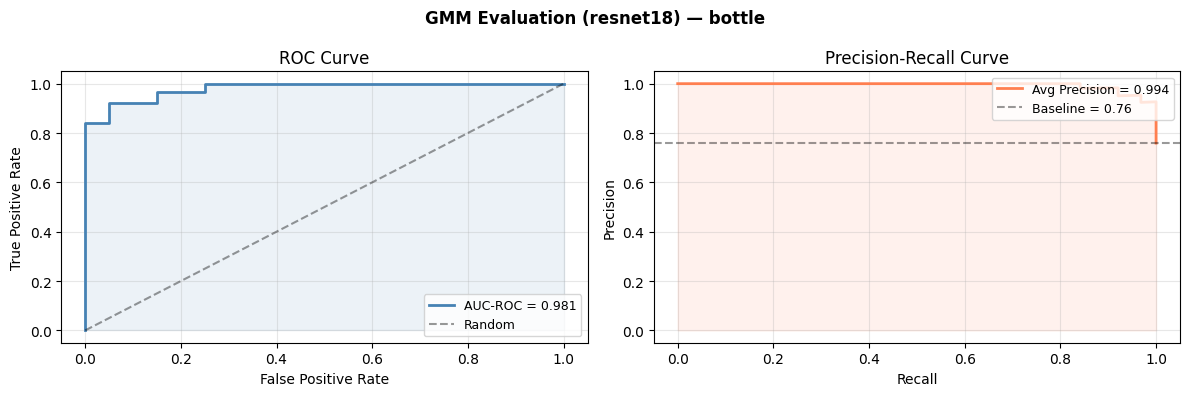

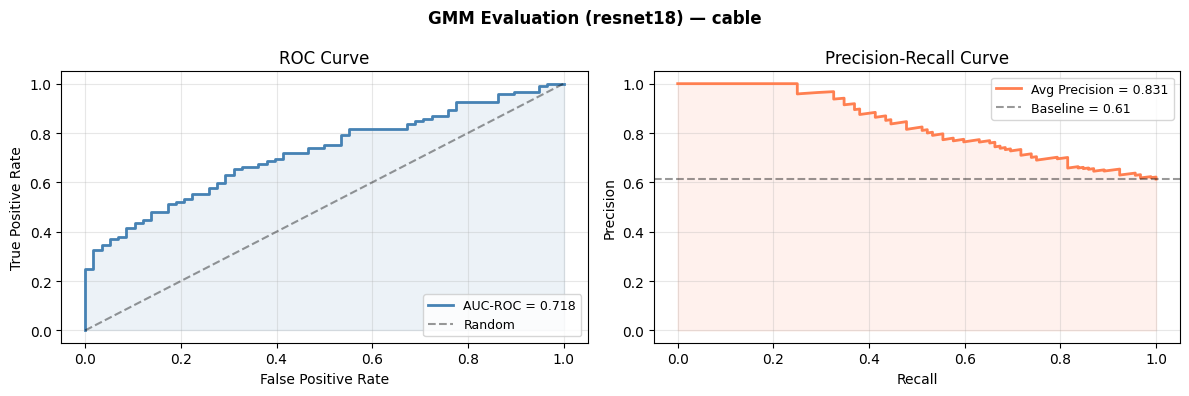

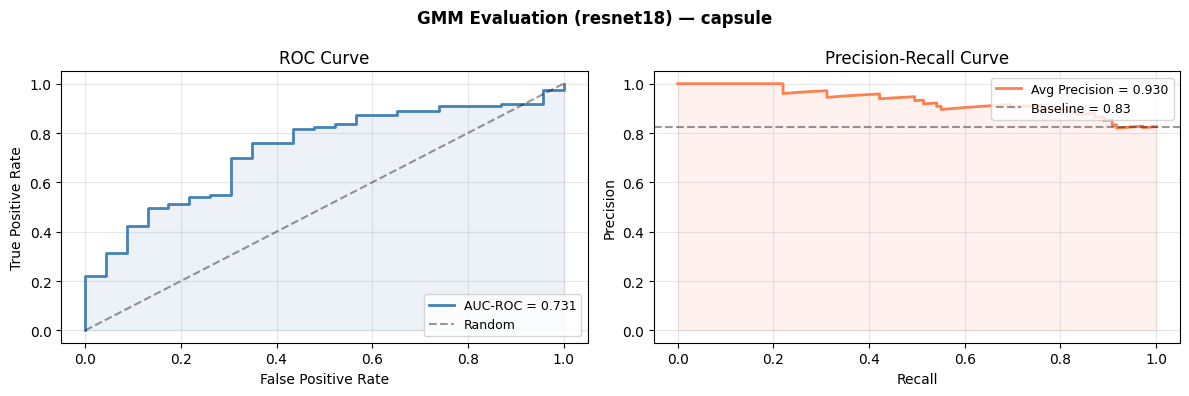

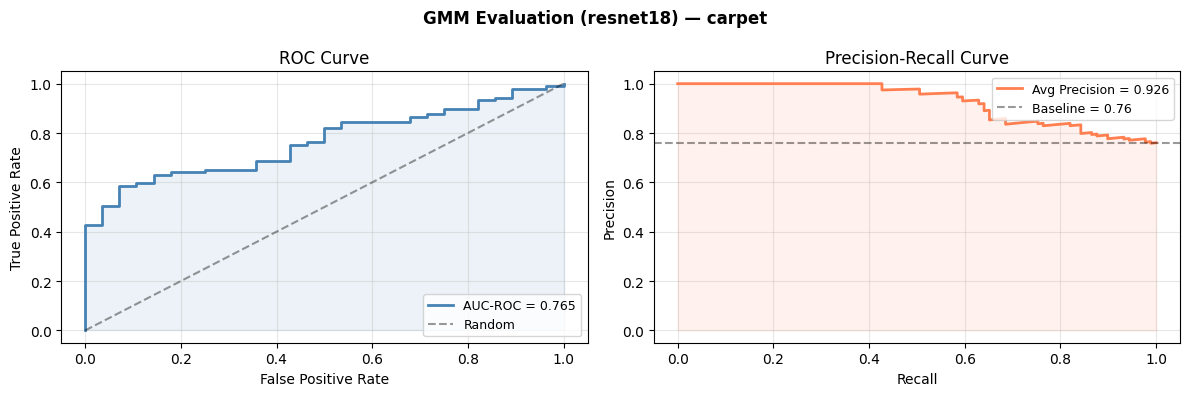

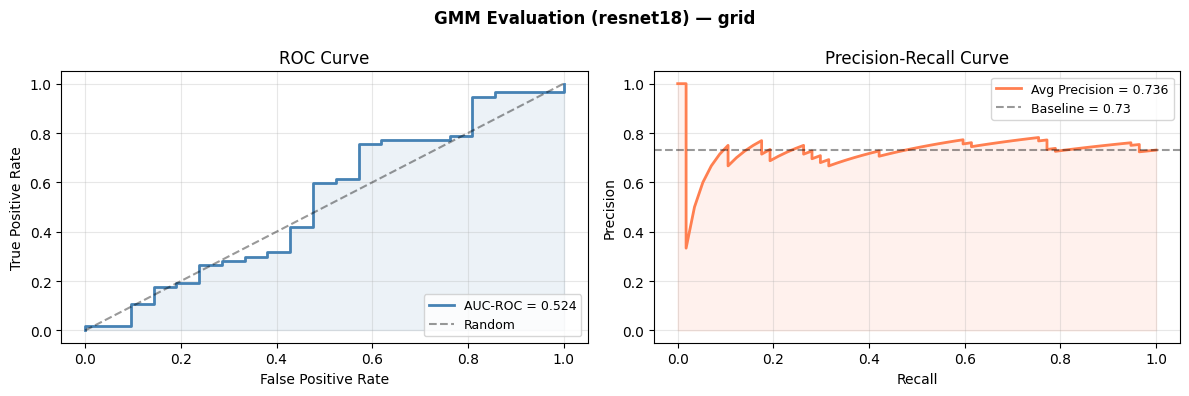

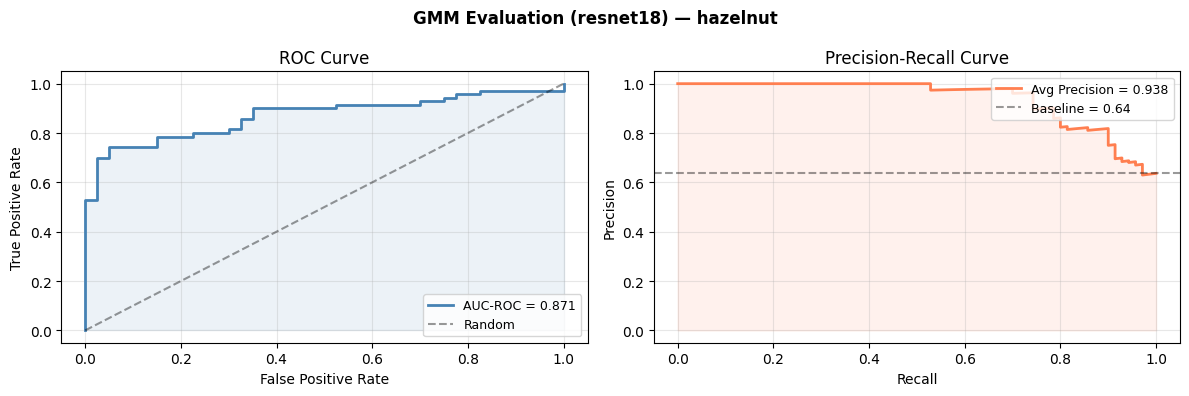

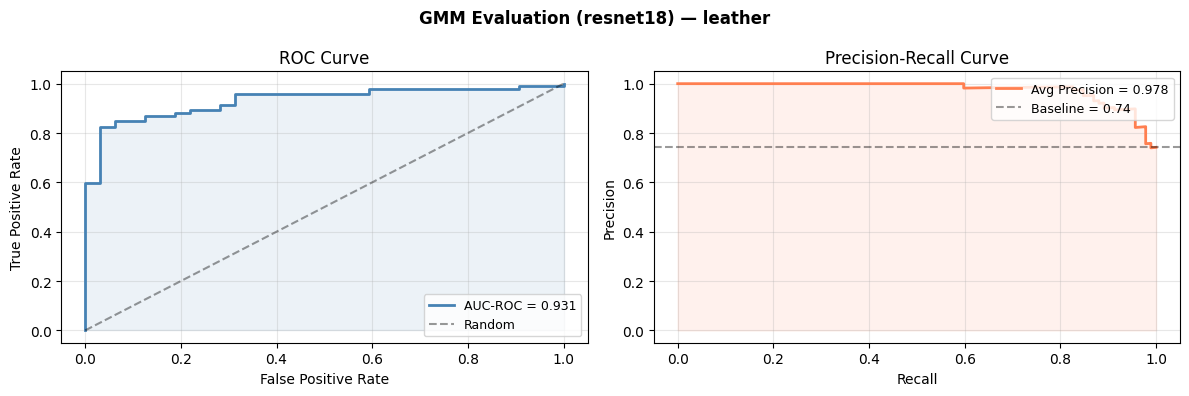

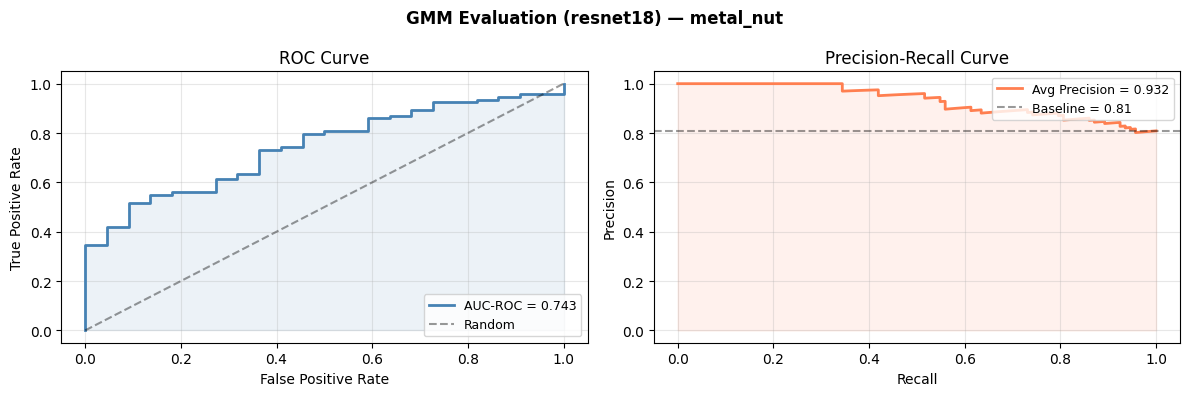

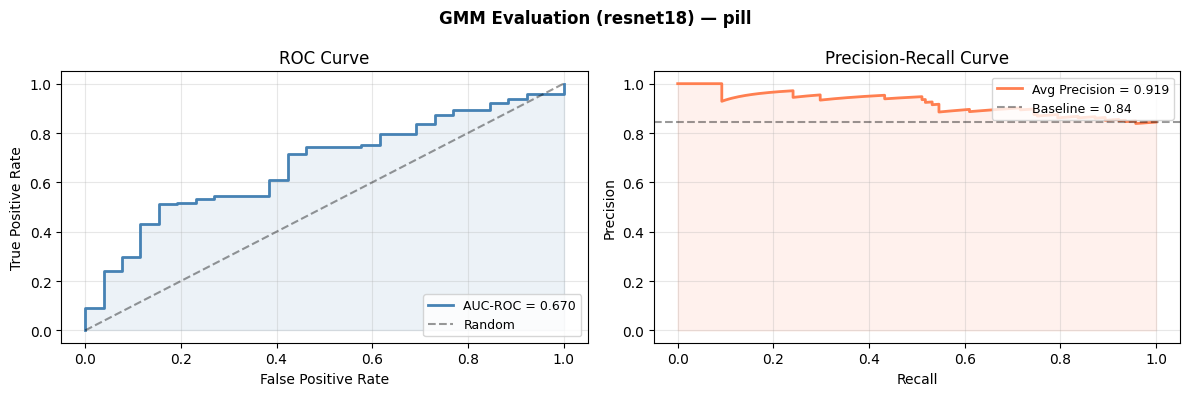

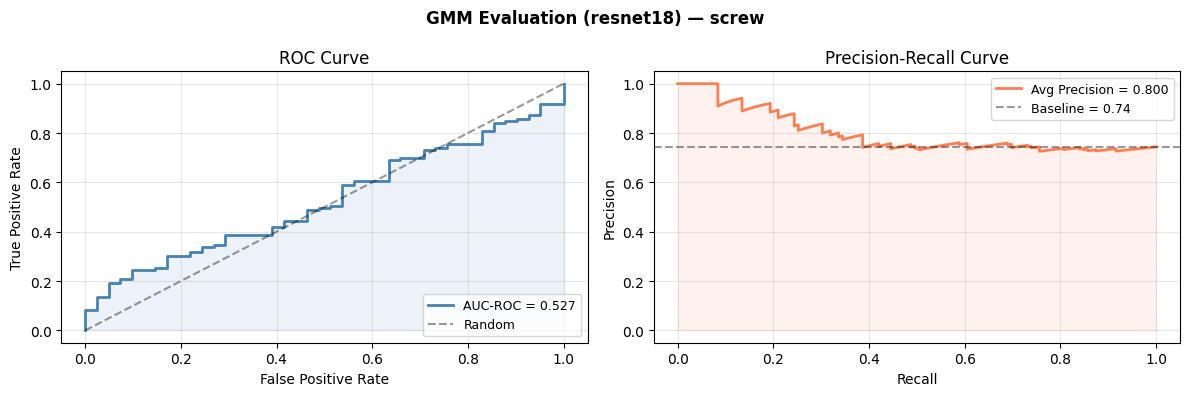

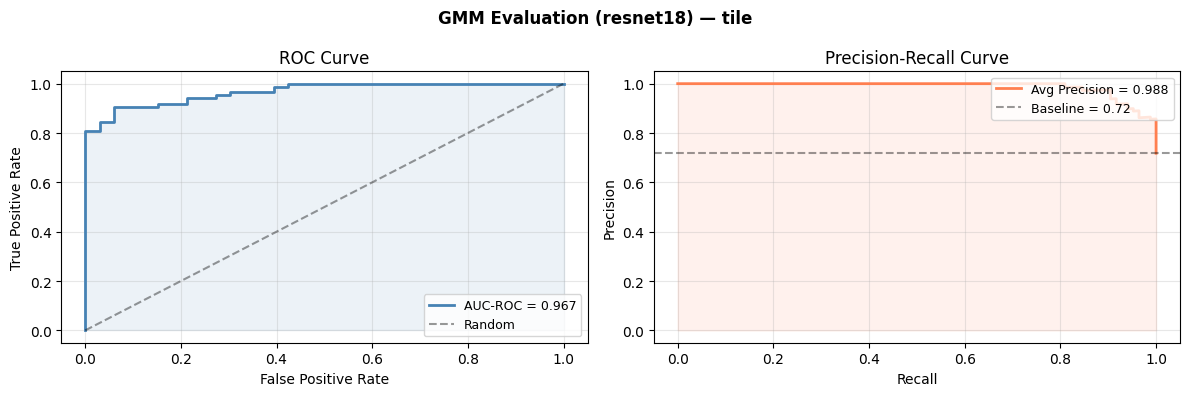

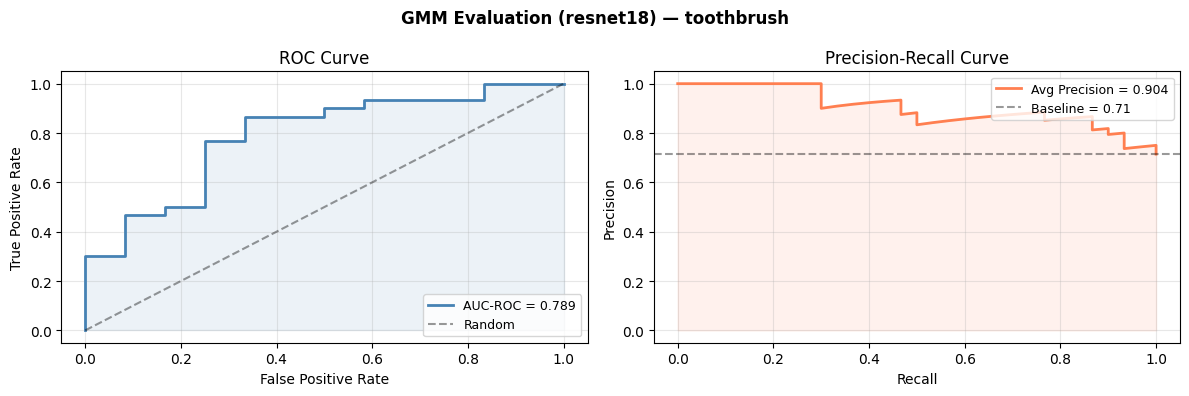

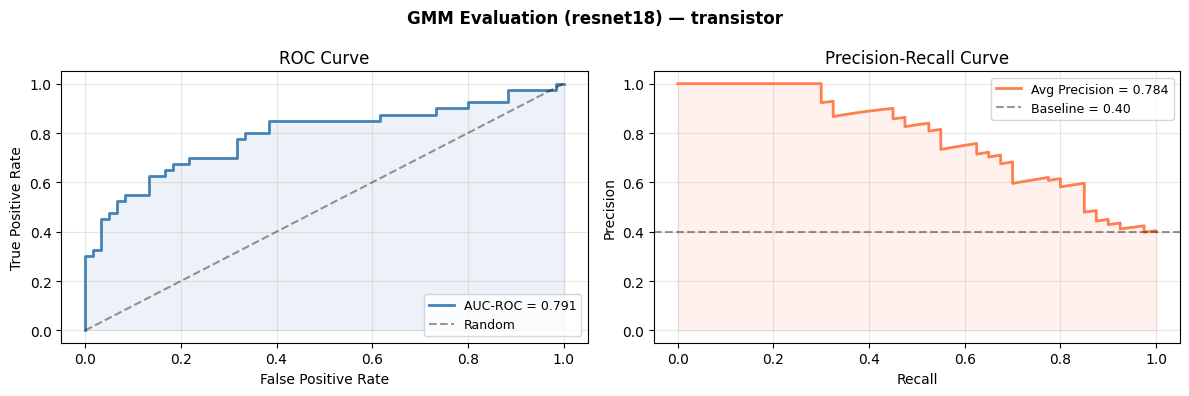

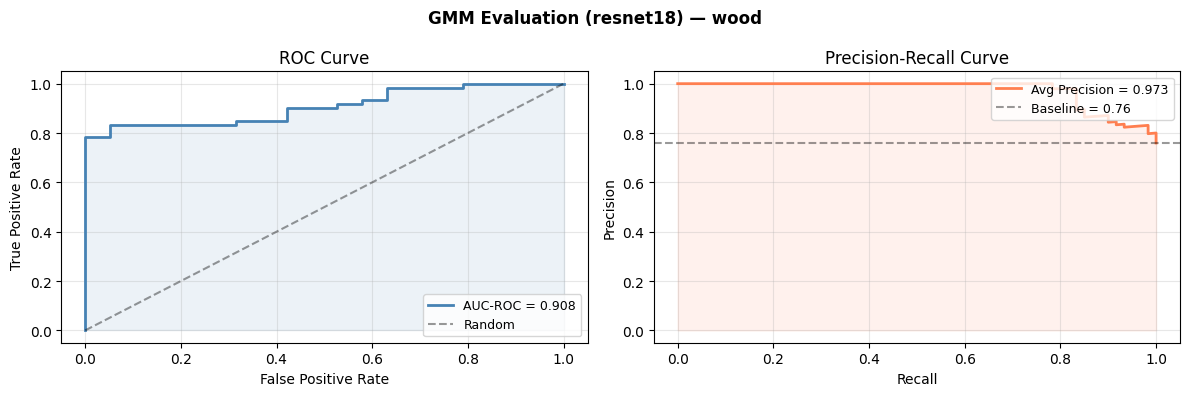

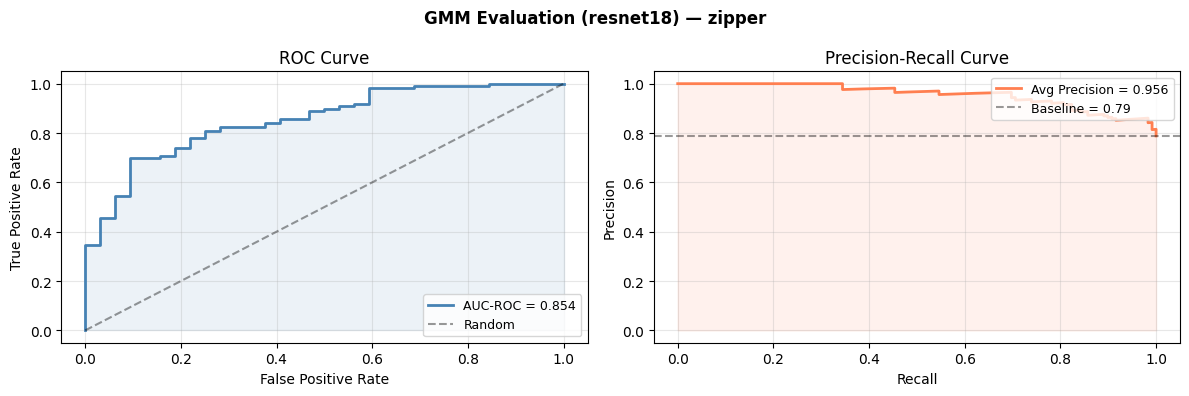

In [13]:
# ── Evaluation: AUC-ROC + Precision-Recall + Threshold Metrics ───────────────
#
# Three complementary metrics:
#
# AUC-ROC: measures ranking ability across all thresholds.
#   Threshold-independent. Primary metric for comparing methods.
#   1.0 = perfect separation, 0.5 = no better than random.
#
# Average Precision (AP): area under the Precision-Recall curve.
#   More informative than AUC-ROC when classes are imbalanced.
#   Test sets are ~75% anomalous, making AP the stronger metric here.
#
# F1 / Precision / Recall at fixed threshold:
#   Threshold = Nth percentile of training Mahalanobis scores.
#   Never derived from test labels — no data leakage.
#   Shows real operational performance when the detector is deployed.
#
# One figure per category: ROC on left, PR on right.
# Summary table printed once at the end covering all categories.

def evaluate_category(cat, score_results, percentile=95):
    train_mahal = score_results[cat]['train_mahal']
    test_mahal  = score_results[cat]['test_mahal']
    labels      = score_results[cat]['labels']
    threshold   = np.percentile(train_mahal, percentile)

    auc_roc              = roc_auc_score(labels, test_mahal)
    fpr, tpr, _          = roc_curve(labels, test_mahal)
    avg_precision        = average_precision_score(labels, test_mahal)
    precision, recall, _ = precision_recall_curve(labels, test_mahal)

    predictions = (test_mahal > threshold).astype(int)
    tp = np.sum((predictions == 1) & (labels == 1))
    tn = np.sum((predictions == 0) & (labels == 0))
    fp = np.sum((predictions == 1) & (labels == 0))
    fn = np.sum((predictions == 0) & (labels == 1))
    prec_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec_t  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1     = (2 * prec_t * rec_t / (prec_t + rec_t)
              if (prec_t + rec_t) > 0 else 0)

    return {
        'auc_roc'        : auc_roc,
        'avg_precision'  : avg_precision,
        'fpr'            : fpr,
        'tpr'            : tpr,
        'precision_curve': precision,
        'recall_curve'   : recall,
        'threshold'      : threshold,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'precision'      : prec_t,
        'recall'         : rec_t,
        'f1'             : f1,
        'labels'         : labels
    }


def plot_evaluation_curves(eval_results, categories):
    """
    One figure per category: ROC curve on left, PR curve on right.
    Each figure is printed before moving to the next category.
    """
    for cat in categories:
        res      = eval_results[cat]
        baseline = res['labels'].mean()

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f'GMM Evaluation ({BACKBONE}) — {cat}',
                     fontsize=12, fontweight='bold')

        # ── Left: ROC Curve ───────────────────────────────────────────────────
        axes[0].plot(res['fpr'], res['tpr'],
                     color='steelblue', linewidth=2,
                     label=f"AUC-ROC = {res['auc_roc']:.3f}")
        axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
        axes[0].fill_between(res['fpr'], res['tpr'],
                             alpha=0.1, color='steelblue')
        axes[0].set(xlabel='False Positive Rate',
                    ylabel='True Positive Rate',
                    title='ROC Curve')
        axes[0].legend(loc='lower right', fontsize=9)
        axes[0].grid(True, alpha=0.3)

        # ── Right: PR Curve ───────────────────────────────────────────────────
        axes[1].plot(res['recall_curve'], res['precision_curve'],
                     color='coral', linewidth=2,
                     label=f"Avg Precision = {res['avg_precision']:.3f}")
        axes[1].fill_between(res['recall_curve'],
                             res['precision_curve'],
                             alpha=0.1, color='coral')
        axes[1].axhline(y=baseline, color='k', linestyle='--',
                        alpha=0.4, label=f'Baseline = {baseline:.2f}')
        axes[1].set(xlabel='Recall',
                    ylabel='Precision',
                    title='Precision-Recall Curve')
        axes[1].legend(loc='upper right', fontsize=9)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


def print_summary_table(eval_results, categories):
    """Prints a single summary table covering all categories."""
    print(f"\n{'='*70}")
    print(f"  {'Category':<15} {'AUC-ROC':>8} {'Avg-Prec':>10} "
          f"{'F1':>7} {'Prec':>7} {'Recall':>8}")
    print(f"{'='*70}")
    for cat in categories:
        res = eval_results[cat]
        print(f"  {cat:<15} {res['auc_roc']:>8.3f} "
              f"{res['avg_precision']:>10.3f} {res['f1']:>7.3f} "
              f"{res['precision']:>7.3f} {res['recall']:>8.3f}")
        print(f"  {'':15} threshold={res['threshold']:.2f}  "
              f"TP={res['tp']}  TN={res['tn']}  "
              f"FP={res['fp']}  FN={res['fn']}\n")
    print(f"{'='*70}")
    avg_auc = np.mean([eval_results[c]['auc_roc'] for c in categories])
    avg_ap  = np.mean([eval_results[c]['avg_precision'] for c in categories])
    avg_f1  = np.mean([eval_results[c]['f1'] for c in categories])
    print(f"  {'AVERAGE':<15} {avg_auc:>8.3f} {avg_ap:>10.3f} {avg_f1:>7.3f}")
    print(f"{'='*70}")


# ── Run evaluation for all categories ────────────────────────────────────────
eval_results = {}
for cat in CATEGORIES:
    eval_results[cat] = evaluate_category(cat, score_results, PERCENTILE)

print_summary_table(eval_results, CATEGORIES)
plot_evaluation_curves(eval_results, CATEGORIES)

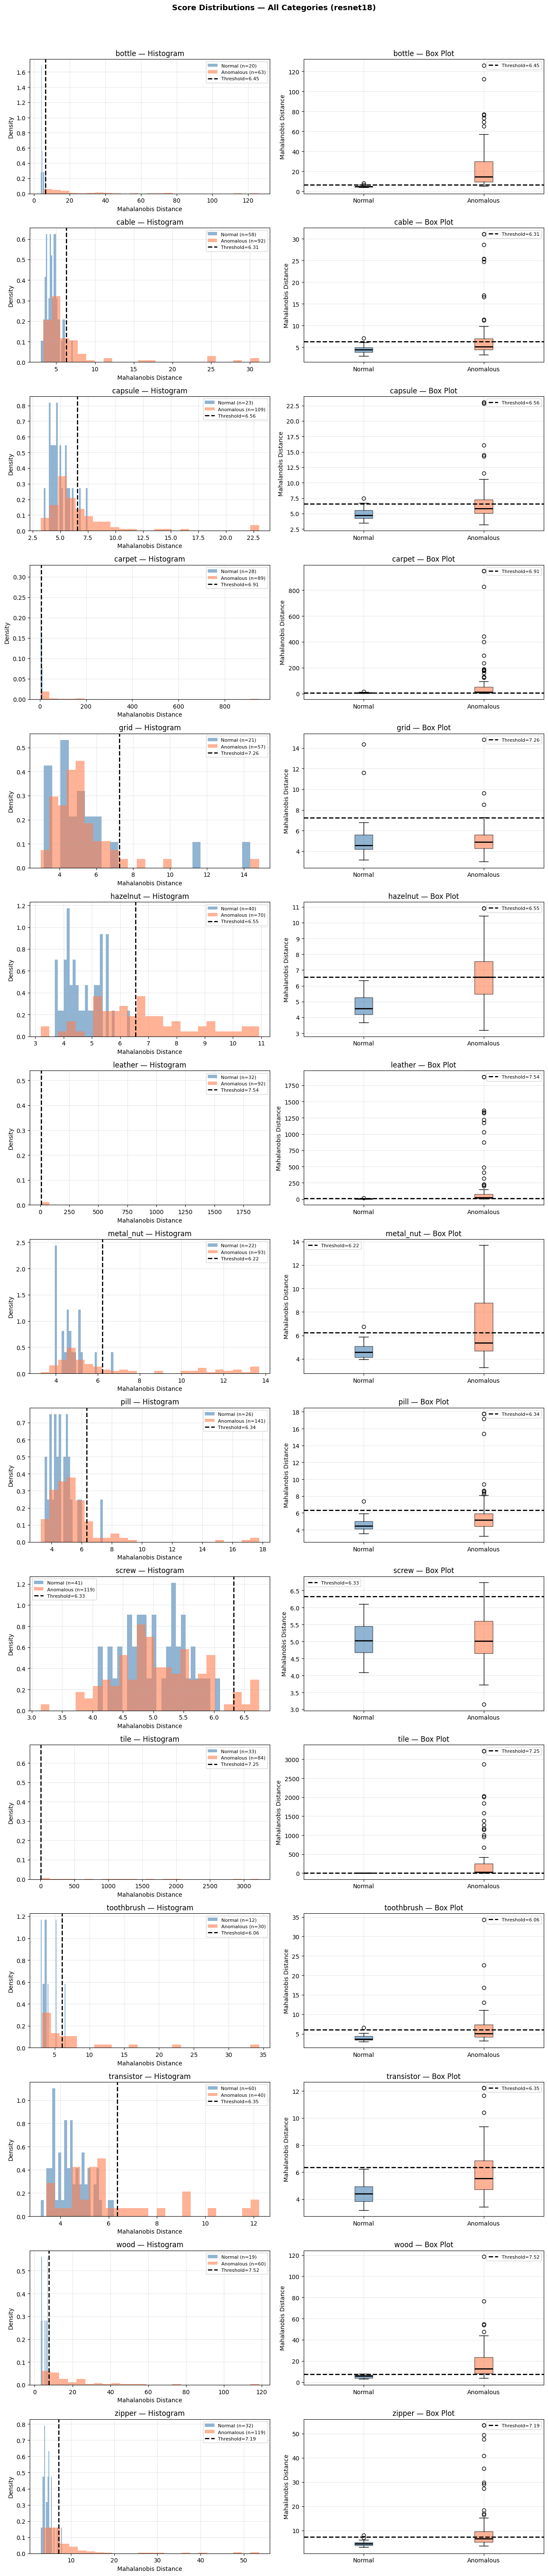


  Score Summary — All Categories
  Category          N-Mean    N-Max   A-Mean    A-Max      Sep
  -------------------------------------------------------
  bottle              4.88     8.24    25.80   189.59    20.92
  cable               4.51     7.14     8.44   143.37     3.93
  capsule             4.96     7.48     6.87    33.09     1.91
  carpet              6.67    15.18    80.43  1299.95    73.75
  grid                5.47    14.35     5.23    16.41    -0.24
  hazelnut            4.69     6.35     6.79    12.58     2.10
  leather             6.38    15.37   189.42  2664.24   183.05
  metal_nut           4.69     6.75     6.91    14.12     2.22
  pill                4.66     7.39     5.57    19.07     0.91
  screw               5.05     6.10     5.15     9.36     0.10
  tile                4.19     7.21   361.88  4325.21   357.69
  toothbrush          4.06     6.56     7.77    42.54     3.71
  transistor          4.45     6.21     6.24    12.33     1.78
  wood                5.42

In [14]:
# ── Score Distribution Plots — All Categories ─────────────────────────────────
# Shows how well normal and anomalous Mahalanobis scores separate per category.
# All categories plotted together in one figure for easy comparison.
#
# Left panel:  Histogram — score density for normal vs anomalous
# Right panel: Box plot  — median, spread, and outliers
# Dashed line: Decision threshold (95th percentile of training scores)
#
# Display only: scores capped at 99th percentile to prevent extreme
# outliers from compressing the x-axis. Actual scores are unchanged.

def plot_all_score_distributions(categories, score_results, percentile=95):
    n_cats = len(categories)
    fig, axes = plt.subplots(n_cats, 2, figsize=(13, 4 * n_cats))
    if n_cats == 1:
        axes = axes.reshape(1, 2)

    fig.suptitle(f'Score Distributions — All Categories ({BACKBONE})',
                 fontsize=13, fontweight='bold', y=1.01)

    for i, cat in enumerate(categories):
        test_mahal       = score_results[cat]['test_mahal']
        train_mahal      = score_results[cat]['train_mahal']
        labels           = score_results[cat]['labels']
        normal_scores    = test_mahal[labels == 0]
        anomalous_scores = test_mahal[labels == 1]
        threshold        = np.percentile(train_mahal, percentile)
        display_cap      = np.percentile(test_mahal, 99)
        normal_disp      = np.clip(normal_scores,    0, display_cap)
        anomalous_disp   = np.clip(anomalous_scores, 0, display_cap)

        # Histogram
        axes[i, 0].hist(normal_disp, bins=25, alpha=0.6, density=True,
                        color='steelblue',
                        label=f'Normal (n={len(normal_scores)})')
        axes[i, 0].hist(anomalous_disp, bins=25, alpha=0.6, density=True,
                        color='coral',
                        label=f'Anomalous (n={len(anomalous_scores)})')
        axes[i, 0].axvline(x=threshold, color='black', linewidth=2,
                           linestyle='--',
                           label=f'Threshold={threshold:.2f}')
        axes[i, 0].set(xlabel='Mahalanobis Distance', ylabel='Density',
                       title=f'{cat} — Histogram')
        axes[i, 0].legend(fontsize=8)
        axes[i, 0].grid(True, alpha=0.3)

        # Box plot
        bp = axes[i, 1].boxplot(
            [normal_disp, anomalous_disp],
            tick_labels=['Normal', 'Anomalous'],
            patch_artist=True,
            medianprops=dict(color='black', linewidth=2)
        )
        bp['boxes'][0].set_facecolor('steelblue')
        bp['boxes'][0].set_alpha(0.6)
        bp['boxes'][1].set_facecolor('coral')
        bp['boxes'][1].set_alpha(0.6)
        axes[i, 1].axhline(y=threshold, color='black', linewidth=2,
                           linestyle='--',
                           label=f'Threshold={threshold:.2f}')
        axes[i, 1].set(ylabel='Mahalanobis Distance',
                       title=f'{cat} — Box Plot')
        axes[i, 1].legend(fontsize=8)
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary table for all categories
    print(f"\n{'='*60}")
    print(f"  Score Summary — All Categories")
    print(f"{'='*60}")
    print(f"  {'Category':<15} {'N-Mean':>8} {'N-Max':>8} "
          f"{'A-Mean':>8} {'A-Max':>8} {'Sep':>8}")
    print(f"  {'-'*55}")
    for cat in categories:
        test_mahal       = score_results[cat]['test_mahal']
        labels           = score_results[cat]['labels']
        normal_scores    = test_mahal[labels == 0]
        anomalous_scores = test_mahal[labels == 1]
        sep = anomalous_scores.mean() - normal_scores.mean()
        print(f"  {cat:<15} "
              f"{normal_scores.mean():>8.2f} "
              f"{normal_scores.max():>8.2f} "
              f"{anomalous_scores.mean():>8.2f} "
              f"{anomalous_scores.max():>8.2f} "
              f"{sep:>8.2f}")
    print(f"{'='*60}")

plot_all_score_distributions(CATEGORIES, score_results, PERCENTILE)

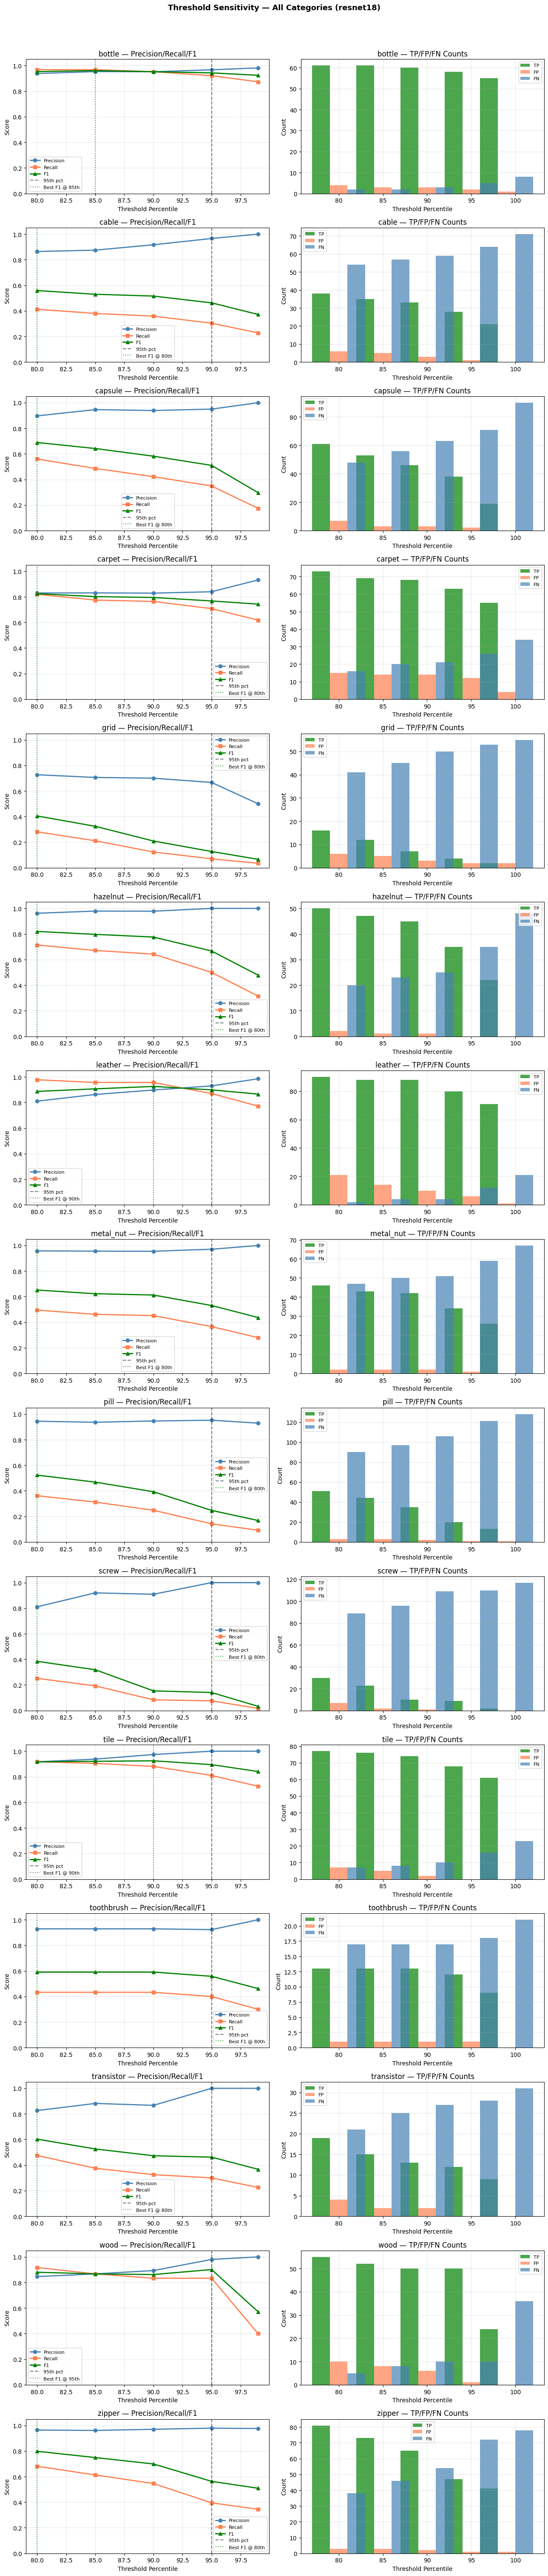


  Threshold Sensitivity Summary
  Category         Best F1   Best Pct    F1@95
  ---------------------------------------------
  bottle             0.961         85    0.943
  cable              0.559         80    0.463
  capsule            0.689         80    0.510
  carpet             0.825         80    0.768
  grid               0.405         80    0.127
  hazelnut           0.820         80    0.667
  leather            0.926         90    0.899
  metal_nut          0.652         80    0.531
  pill               0.523         80    0.247
  screw              0.385         80    0.141
  tile               0.925         90    0.895
  toothbrush         0.591         80    0.558
  transistor         0.603         80    0.462
  wood               0.901         95    0.901
  zipper             0.798         80    0.563


In [15]:
# ── Threshold Sensitivity — All Categories ────────────────────────────────────
# Sweeps threshold percentiles from 80 to 99 for every category.
# All categories plotted together in one figure.
#
# Left panel:  Precision, Recall, F1 vs percentile
# Right panel: TP / FP / FN counts vs percentile
#
# Key insight: higher threshold = fewer false alarms, more missed defects.
# Best F1 percentile varies by category — reported in the printed table.
# Directly addresses RQ2 from the proposal: balancing sensitivity vs
# false-positive rate across diverse defect categories.

PERCENTILES_TO_TEST = [80, 85, 90, 95, 99]

def compute_threshold_sweep(cat, score_results, percentiles):
    train_mahal = score_results[cat]['train_mahal']
    test_mahal  = score_results[cat]['test_mahal']
    labels      = score_results[cat]['labels']
    rows = []
    for pct in percentiles:
        threshold   = np.percentile(train_mahal, pct)
        predictions = (test_mahal > threshold).astype(int)
        tp = np.sum((predictions == 1) & (labels == 1))
        tn = np.sum((predictions == 0) & (labels == 0))
        fp = np.sum((predictions == 1) & (labels == 0))
        fn = np.sum((predictions == 0) & (labels == 1))
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
        rows.append({
            'percentile': pct, 'threshold': round(threshold, 3),
            'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'precision': round(prec, 3),
            'recall': round(rec, 3),
            'f1': round(f1, 3)
        })
    return pd.DataFrame(rows)

def plot_all_threshold_experiments(categories, score_results, percentiles):
    n_cats = len(categories)
    fig, axes = plt.subplots(n_cats, 2, figsize=(13, 4 * n_cats))
    if n_cats == 1:
        axes = axes.reshape(1, 2)

    fig.suptitle(f'Threshold Sensitivity — All Categories ({BACKBONE})',
                 fontsize=13, fontweight='bold', y=1.01)

    dfs = {}
    for i, cat in enumerate(categories):
        df   = compute_threshold_sweep(cat, score_results, percentiles)
        dfs[cat] = df
        best = df.loc[df['f1'].idxmax()]

        axes[i, 0].plot(df['percentile'], df['precision'], 'o-',
                        color='steelblue', linewidth=2, label='Precision')
        axes[i, 0].plot(df['percentile'], df['recall'],    's-',
                        color='coral',    linewidth=2, label='Recall')
        axes[i, 0].plot(df['percentile'], df['f1'],        '^-',
                        color='green',    linewidth=2, label='F1')
        axes[i, 0].axvline(x=95, color='black', linestyle='--',
                           alpha=0.5, label='95th pct')
        axes[i, 0].axvline(x=best['percentile'], color='green',
                           linestyle=':', alpha=0.7,
                           label=f"Best F1 @ {int(best['percentile'])}th")
        axes[i, 0].set(xlabel='Threshold Percentile', ylabel='Score',
                       title=f'{cat} — Precision/Recall/F1',
                       ylim=(0, 1.05))
        axes[i, 0].legend(fontsize=8)
        axes[i, 0].grid(True, alpha=0.3)

        x = df['percentile']
        axes[i, 1].bar(x - 2, df['TP'], width=2, color='green',
                       alpha=0.7, label='TP')
        axes[i, 1].bar(x,     df['FP'], width=2, color='coral',
                       alpha=0.7, label='FP')
        axes[i, 1].bar(x + 2, df['FN'], width=2, color='steelblue',
                       alpha=0.7, label='FN')
        axes[i, 1].set(xlabel='Threshold Percentile', ylabel='Count',
                       title=f'{cat} — TP/FP/FN Counts')
        axes[i, 1].legend(fontsize=8)
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary across all categories
    print(f"\n{'='*60}")
    print(f"  Threshold Sensitivity Summary")
    print(f"{'='*60}")
    print(f"  {'Category':<15} {'Best F1':>8} {'Best Pct':>10} "
          f"{'F1@95':>8}")
    print(f"  {'-'*45}")
    for cat in categories:
        df       = dfs[cat]
        best     = df.loc[df['f1'].idxmax()]
        f1_at_95 = df[df['percentile'] == 95]['f1'].values[0]
        print(f"  {cat:<15} {best['f1']:>8.3f} "
              f"{int(best['percentile']):>10} "
              f"{f1_at_95:>8.3f}")
    print(f"{'='*60}")

    return dfs

threshold_dfs = plot_all_threshold_experiments(
    CATEGORIES, score_results, PERCENTILES_TO_TEST
)

In [16]:
# ── Save All Results to Drive ─────────────────────────────────────────────────
# Per-category files saved in separate subfolders.
# Combined CSV accumulates results across runs — re-running one category
# updates only that row without overwriting other categories.
# Backbone name included in all paths so ResNet18 and ResNet50 never mix.

SAVE_PATH = os.path.join(
    '/content/drive/MyDrive/Zero Shot Anomaly Detection',
    'results', f'gmm_{BACKBONE}'
)
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Saving to: {SAVE_PATH}\n")

current_run_rows = []

for cat in CATEGORIES:
    cat_dir = os.path.join(SAVE_PATH, cat)
    os.makedirs(cat_dir, exist_ok=True)

    labels      = score_results[cat]['labels']
    test_mahal  = score_results[cat]['test_mahal']
    test_loglik = score_results[cat]['test_loglik']
    threshold   = eval_results[cat]['threshold']
    predictions = (test_mahal > threshold).astype(int)

    pd.DataFrame({
        'category'       : cat,
        'true_label'     : labels,
        'mahal_score'    : test_mahal,
        'loglik_score'   : test_loglik,
        'predicted_label': predictions,
        'correct'        : (predictions == labels).astype(int)
    }).to_csv(os.path.join(cat_dir, 'anomaly_scores.csv'), index=False)

    res        = eval_results[cat]
    metrics_df = pd.DataFrame([{
        'category'      : cat,
        'method'        : 'GMM',
        'backbone'      : BACKBONE,
        'pca_dims'      : PCA_N_COMPONENTS,
        'gmm_k'         : gmm_results[cat]['best_k'],
        'threshold_pct' : PERCENTILE,
        'threshold_val' : round(res['threshold'], 4),
        'auc_roc'       : round(res['auc_roc'], 4),
        'avg_precision' : round(res['avg_precision'], 4),
        'f1'            : round(res['f1'], 4),
        'precision'     : round(res['precision'], 4),
        'recall'        : round(res['recall'], 4),
        'tp': res['tp'], 'tn': res['tn'],
        'fp': res['fp'], 'fn': res['fn'],
        'n_train'       : len(score_results[cat]['train_mahal']),
        'n_test_normal' : int(np.sum(labels == 0)),
        'n_test_anomaly': int(np.sum(labels == 1))
    }])
    metrics_df.to_csv(
        os.path.join(cat_dir, 'metrics_summary.csv'), index=False
    )

    sweep_df = threshold_dfs[cat].copy()
    sweep_df.insert(0, 'category', cat)
    sweep_df.to_csv(
        os.path.join(cat_dir, 'threshold_sweep.csv'), index=False
    )

    current_run_rows.append(metrics_df)
    print(f"  [{cat}] saved  "
          f"(AUC={res['auc_roc']:.3f}  AP={res['avg_precision']:.3f}  "
          f"F1={res['f1']:.3f})")

# Smart merge with existing combined CSV
combined_path  = os.path.join(SAVE_PATH, f'gmm_{BACKBONE}_all_results.csv')
current_run_df = pd.concat(current_run_rows, ignore_index=True)

if os.path.exists(combined_path):
    existing_df = pd.read_csv(combined_path)
    existing_df = existing_df[
        ~existing_df['category'].isin(current_run_df['category'])
    ]
    combined_df = pd.concat(
        [existing_df, current_run_df], ignore_index=True
    ).sort_values('category').reset_index(drop=True)
    print(f"\nUpdated existing combined CSV")
else:
    combined_df = current_run_df
    print(f"\nCreated new combined CSV")

combined_df.to_csv(combined_path, index=False)

print(f"\n{'='*70}")
print(f"  Final Results — GMM ({BACKBONE})")
print(f"{'='*70}")
print(combined_df[['category', 'backbone', 'auc_roc',
                   'avg_precision', 'f1',
                   'precision', 'recall']].to_string(index=False))
print(f"{'='*70}")
print(f"\nAverage AUC-ROC : {combined_df['auc_roc'].mean():.4f}")
print(f"Average Avg-Prec: {combined_df['avg_precision'].mean():.4f}")
print(f"Average F1      : {combined_df['f1'].mean():.4f}")
print(f"\nSaved: {combined_path}")

Saving to: /content/drive/MyDrive/Zero Shot Anomaly Detection/results/gmm_resnet18

  [bottle] saved  (AUC=0.981  AP=0.994  F1=0.943)
  [cable] saved  (AUC=0.718  AP=0.831  F1=0.463)
  [capsule] saved  (AUC=0.731  AP=0.930  F1=0.510)
  [carpet] saved  (AUC=0.765  AP=0.926  F1=0.768)
  [grid] saved  (AUC=0.524  AP=0.736  F1=0.127)
  [hazelnut] saved  (AUC=0.871  AP=0.938  F1=0.667)
  [leather] saved  (AUC=0.931  AP=0.978  F1=0.899)
  [metal_nut] saved  (AUC=0.743  AP=0.932  F1=0.531)
  [pill] saved  (AUC=0.670  AP=0.919  F1=0.247)
  [screw] saved  (AUC=0.527  AP=0.800  F1=0.141)
  [tile] saved  (AUC=0.967  AP=0.988  F1=0.895)
  [toothbrush] saved  (AUC=0.789  AP=0.904  F1=0.558)
  [transistor] saved  (AUC=0.791  AP=0.784  F1=0.462)
  [wood] saved  (AUC=0.908  AP=0.973  F1=0.901)
  [zipper] saved  (AUC=0.854  AP=0.956  F1=0.563)

Created new combined CSV

  Final Results — GMM (resnet18)
  category backbone  auc_roc  avg_precision     f1  precision  recall
    bottle resnet18   0.9810   